In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from IPython.display import display

In [2]:
df = pd.read_csv("Cleaned_Transactions_Merged.csv")
df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Transaction_Type,Satisfaction_Score,Feedback_Comments,Likelihood_to_Recommend
0,1,393,2023-01-01 00:00:00,3472.0,Purchase,1.0,Excellent,3
1,2,826,2023-01-01 01:00:00,2460.0,Bill Payment,6.0,Needs improvement,3
2,3,916,2023-01-01 02:00:00,10.0,Purchase,6.0,Needs improvement,3
3,4,109,2023-01-01 03:00:00,72.0,Investment,3.0,Good service,9
4,5,889,2023-01-01 04:00:00,1793.0,Investment,8.0,Very satisfied,3


In [3]:
# Features intended for clustering
features = [
    'Transaction_Amount',
    'Satisfaction_Score',
    'Likelihood_to_Recommend'
]

# Column Existence Check
missing_columns = [col for col in features if col not in df.columns]

if missing_columns:
    print("⚠ Missing required columns:", missing_columns)
else:
    print("All required columns are present.")

    # Input Validation (NaN Check)
    if df[features].isnull().values.any():
        print("⚠ Warning: Missing values detected in clustering features.")

        print("Missing values per column:")
        print(df[features].isnull().sum())

        # Fix missing values
        df[features] = df[features].fillna(df[features].mean())

        print("Missing values filled using column means.")

    else:
        print("Data validation passed. No missing values detected.")

All required columns are present.
Data validation passed. No missing values detected.


In [4]:
# Aggregate transaction-level data to customer-level
customer_df = df.groupby("Customer_ID").agg({
    "Transaction_Amount": ["sum", "mean", "count"],
    "Satisfaction_Score": "mean",
    "Likelihood_to_Recommend": "mean"
})

customer_df.columns = [
    "Total_Spend",
    "Avg_Transaction",
    "Transaction_Frequency",
    "Avg_Satisfaction",
    "Avg_Likelihood"
]

customer_df = customer_df.reset_index()

In [5]:
features = customer_df[
    [
        "Total_Spend",
        "Avg_Transaction",
        "Transaction_Frequency",
        "Avg_Satisfaction",
        "Avg_Likelihood"
    ]
]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


In [6]:
# Run PCA to justify feature selection
pca_justification = PCA(n_components=2)
pca_justification.fit(scaled_features) 

# Create a DataFrame to see how much each feature contributes to the Principal Components
loadings = pd.DataFrame(
    pca_justification.components_.T, 
    columns=['Principal Component 1', 'Principal Component 2'], 
    index=features.columns 
)

print("PCA Feature Loadings (Mathematical Justification for Feature Importance):")
display(loadings.round(3))

PCA Feature Loadings (Mathematical Justification for Feature Importance):


,Principal Component 1,Principal Component 2
Total_Spend,0.708,-0.017
Avg_Transaction,0.323,-0.532
Transaction_Frequency,0.628,0.275
Avg_Satisfaction,0.019,0.617
Avg_Likelihood,0.001,-0.511


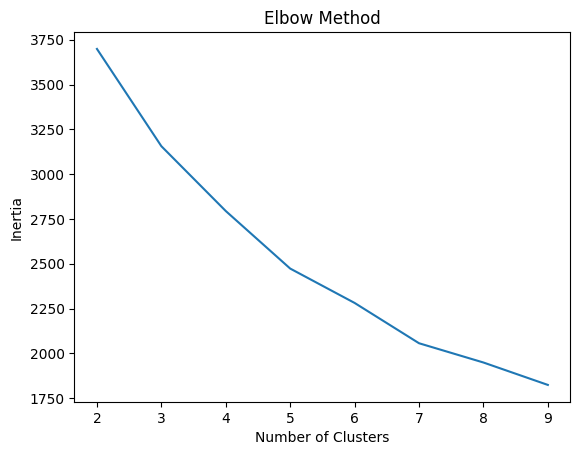

K=2, Silhouette Score=0.225
K=3, Silhouette Score=0.198
K=4, Silhouette Score=0.188
K=5, Silhouette Score=0.196
K=6, Silhouette Score=0.193


In [7]:
inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(2, 10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")


In [8]:
try:
    kmeans = KMeans(n_clusters=2, random_state=42)
    customer_df["Cluster"] = kmeans.fit_predict(scaled_features)

    print("Clustering completed successfully.")

except KeyError as e:
    print(f"Column error detected: {e}")

except ValueError as e:
    print(f"Data formatting issue detected: {e}")

except Exception as e:
    print(f"Unexpected clustering error: {e}")


Clustering completed successfully.


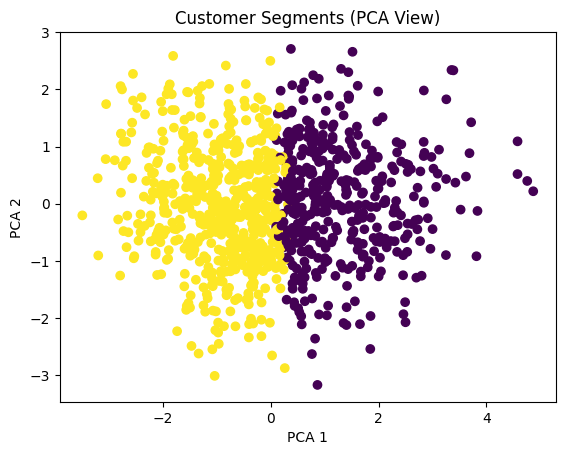

In [9]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

plt.figure()
plt.scatter(pca_features[:,0], pca_features[:,1], c=customer_df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments (PCA View)")
plt.show()


In [10]:
def generate_cluster_report(df, groupby_col="Cluster"):
    """
    Generate a cluster summary table.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset containing cluster labels and features.

    groupby_col : str
        Column used to group clusters.

    Returns
    -------
    pandas.DataFrame
        Summary statistics for each cluster.
    """

    try:
        cluster_summary = df.groupby(groupby_col).mean()
        return cluster_summary

    except KeyError as e:
        print(f"Column error while generating cluster report: {e}")

    except Exception as e:
        print(f"Unexpected error while generating cluster report: {e}")


In [11]:
cluster_summary = generate_cluster_report(customer_df)

cluster_summary = cluster_summary.drop(columns=["Customer_ID"], errors="ignore")

display(cluster_summary.round(2))

,Total_Spend,Avg_Transaction,Transaction_Frequency,Avg_Satisfaction,Avg_Likelihood
Cluster,,,,,
0,18479.82,2722.39,6.93,5.56,5.46
1,8118.34,2322.10,3.62,5.51,5.45
